# 📰 AG News Dataset: Exploratory Data Analysis

In [ ]:
# Environment Setup & Dependency Installation

import sys
import os
import shutil
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

# Detect Environment
def in_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IS_COLAB = in_colab()
PYTHON_VERSION = sys.version.split()[0]

print(f"Environment Detected: {'Google Colab' if IS_COLAB else 'Local VS Code / Jupyter'}")
print(f"Kernel Python Version: {PYTHON_VERSION}\n")

# Packages to install
# Ensure PEFT is included for Model C
PACKAGES = "transformers datasets evaluate nltk seaborn matplotlib accelerate numpy pandas torch scikit-learn peft" 

if IS_COLAB:
    # --- Colab-Specific Installation ---
    try:
        import pyarrow
        import datasets
        import evaluate
        import sklearn
        NEEDS_INSTALL = False
    except (ImportError, ValueError):
        NEEDS_INSTALL = True

    if NEEDS_INSTALL:
        print("Installing/Updating core dependencies...")
        !pip install -q pyarrow
        !pip install -q {PACKAGES}
        print("✓ Dependencies installed/updated!")
        print("⚠️  Restarting Runtime...")
        print("📝 Re-run the Notebook...")
        time.sleep(2)
        os.kill(os.getpid(), 9)
    else:
        print("✓ Dependencies already installed!")
else:
    # --- Local Jupyter/VS Code Installation ---\n",
    print("Installing/Updating core dependencies")
    try:
        if 'get_ipython' in globals():
            cell_content = f"%%capture\n%pip install -U {PACKAGES}"
            get_ipython().run_cell(cell_content)
            print("✓ Dependencies installed/updated!")
        else:
            print("⚠️  Installation failed: Not running in interactive environment. Run manually.")
    except NameError:
        print("⚠️  Installation failed: Not running in a standard Jupyter kernel. Run manually.")

Environment Detected: Local VS Code / Jupyter
Kernel Python Version: 3.12.10

Installing/Updating core dependencies
✓ Dependencies installed/updated!


In [2]:
# ==========================================================
# CELL 2: Library Imports
# ==========================================================

import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='tqdm')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer
from IPython.display import display
import nltk
from nltk.tokenize import sent_tokenize
from nltk.corpus import stopwords
from collections import Counter
import re

# ==========================================================
# Utility Functions
# ==========================================================

def pretty(df, precision=2):
    """Returns a styled DataFrame for visual output."""
    return (
        df.style
        .format(precision=precision)
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', '#e8e8e8'), ('font-weight', 'bold'), 
                                          ('color', 'black'), ('padding', '8px'), ('border', '1px solid #cccccc')]},
            {'selector': 'td', 'props': [('padding', '6px'), ('border', '1px solid #dddddd'), 
                                          ('color', 'black'), ('background-color', 'white')]}
        ])
        .apply(lambda col: ['background-color: #f9f9f9' if i % 2 else 'background-color: white'
                            for i in range(len(col))], axis=0)
    )

# ==========================================================
# Plotting Setup
# ==========================================================

plt.rcParams.update({
    "figure.figsize": (10, 6), 
    "axes.titlesize": 18, 
    "axes.labelsize": 14,
    "xtick.labelsize": 12, 
    "ytick.labelsize": 12, 
    "grid.alpha": 0.3, 
    "figure.dpi": 130
})
sns.set_theme(style="whitegrid", palette="pastel")

# ==========================================================
# NLTK Setup
# ==========================================================

print(" Downloading NLTK resources...")
for resource in ["punkt", "stopwords", "punkt_tab"]:
    try:
        if resource == "punkt_tab":
            nltk.data.find(f"tokenizers/{resource}")
        elif resource == "stopwords":
            nltk.data.find(f"corpora/{resource}")
        else:
            nltk.data.find(f"tokenizers/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

stop_words = set(stopwords.words("english"))

print("\n" + "="*60)
print("✅ All Libraries Imported Successfully")
print("="*60 + "\n")

c:\Users\joaqu\AI-News-Classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



✅ All Libraries Imported Successfully



In [3]:
# ==========================================================
# CELL 3: Configuration and Data Loading
# ==========================================================

# Define constants (consistent with other notebooks)
CLASS_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
MODEL_CKPT = "distilbert-base-uncased"

print("📂 Loading AG News Dataset...\n")

dataset = load_dataset("ag_news")

print(f"{'='*60}")
print("DATASET STRUCTURE")
print(f"{'='*60}")
print(dataset)
print(f"\n📊 Class Mapping: {CLASS_NAMES}")
print(f"{'='*60}\n")

# Create DataFrames
train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print(f"📋 Columns: {train_df.columns.tolist()}\n")

# Set primary DataFrame for EDA (no unnecessary copy)
df = train_df
df["category"] = df["label"].map(CLASS_NAMES)

print("✅ Initial data loaded. 'df' is set to the training split for EDA.\n")
print(f"{'='*60}")
print("SAMPLE DATA")
print(f"{'='*60}")
display(df.head())

📂 Loading AG News Dataset...

DATASET STRUCTURE
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

📊 Class Mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}

📋 Columns: ['text', 'label']

✅ Initial data loaded. 'df' is set to the training split for EDA.

SAMPLE DATA


,text,label,category
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business


## Raw Data Analysis

This section performs **exploratory data analysis (EDA)** on the raw text of the Hugging Face `ag_news` dataset **before any cleaning or tokenization**.

The goals are:
- Understand text length, word counts, and sentence counts
- Inspect dataset balance and category-wise length differences
- Analyze case usage (uppercase vs lowercase)
- Identify punctuation and special character patterns
- Examine vocabulary and word length characteristics
- Perform data quality checks (nulls, duplicates, very short texts)

A later section will define the **preprocessing + tokenization pipeline** once the raw data is fully understood.


1. DATA QUALITY CHECK



,Missing Values,Duplicate Text Count
text,0,0
label,0,
category,0,


✅ CONCLUSION: Data is clean (0 Nulls, 0 Duplicates). Proceeding with analysis.

2. LABEL DISTRIBUTION



,Count
category,
Business,30000
Sci/Tech,30000
Sports,30000
World,30000



✅ CONCLUSION: The dataset is perfectly balanced across all categories.
   This simplifies training and eliminates the need for resampling.



C:\Users\joaqu\AppData\Local\Temp\ipykernel_28752\2525512707.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="pastel")


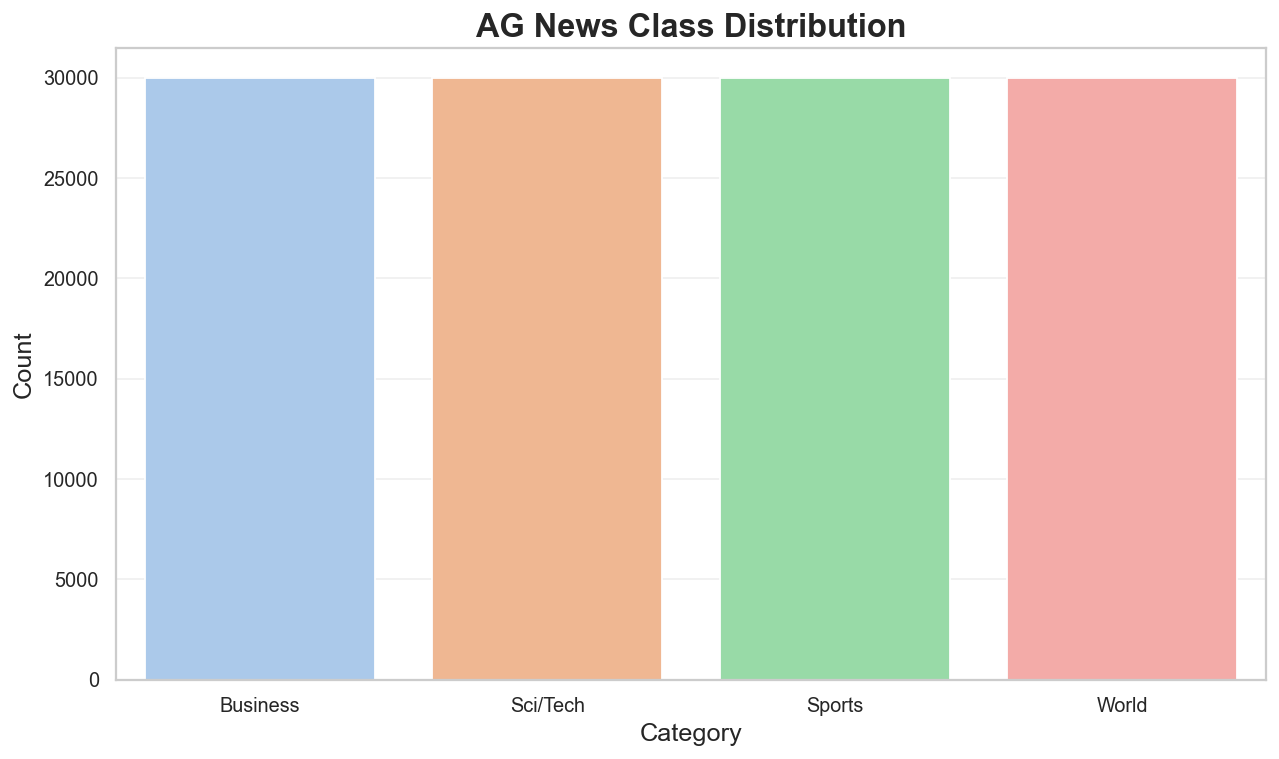


3. TEXT LENGTH ANALYSIS

Text Length Summary:


,num_chars,num_words,num_sentences,avg_word_len_article
count,120000.00,120000.00,120000.00,120000.00
mean,236.48,37.85,1.32,5.29
std,66.51,10.09,0.66,0.69
min,100.00,8.00,1.00,3.36
25%,196.00,32.00,1.00,4.87
50%,232.00,37.00,1.00,5.20
75%,266.00,43.00,1.00,5.57
max,1012.00,177.00,15.00,20.80



✅ RATIONALE: The 75th percentile for word count is 43.
   A standard transformer MAX_LENGTH of 128 tokens is highly efficient
   and sufficient to capture all article content without excessive
   truncation or padding.



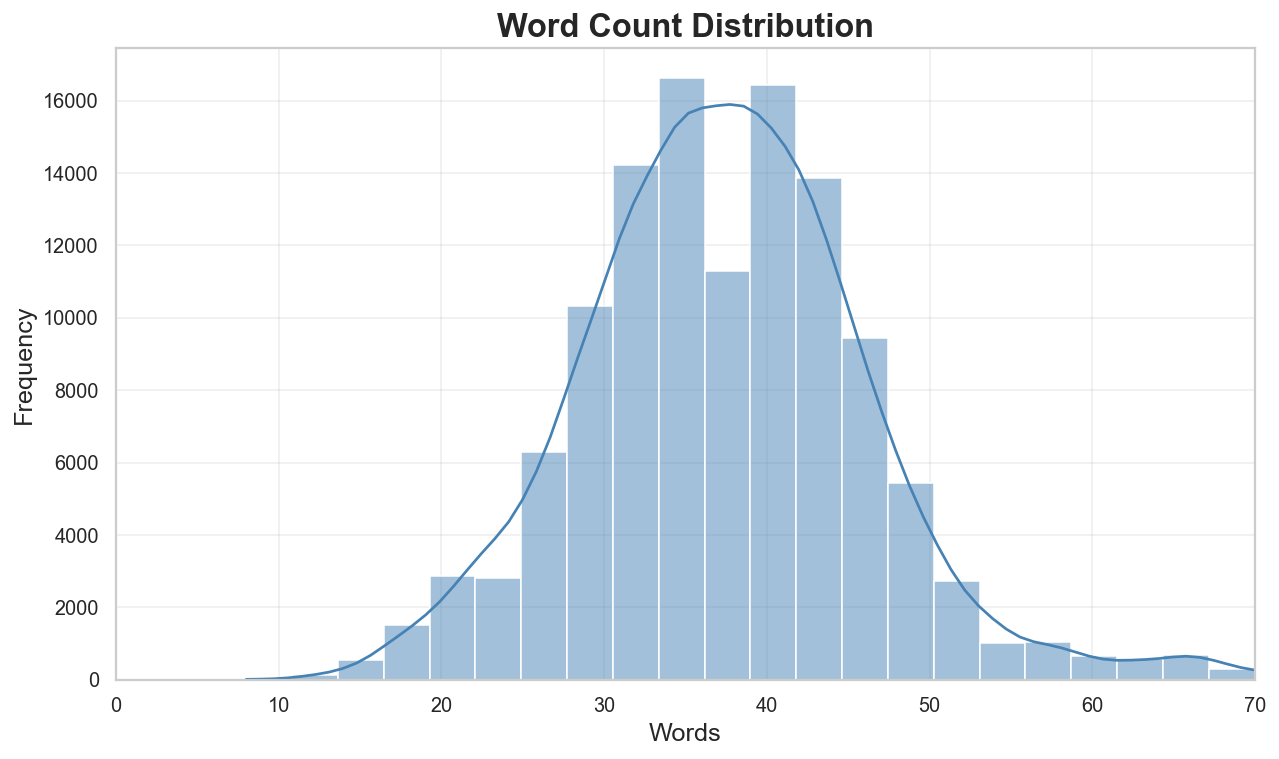


4. CASE AND PUNCTUATION ANALYSIS

Case and Punctuation Summary:


,num_upper,num_lower,upper_ratio,num_punct
count,120000.00,120000.00,120000.00,120000.00
mean,14.55,174.08,0.08,4.23
std,8.09,48.65,0.04,3.50
min,1.00,0.00,0.00,0.00
25%,9.00,144.00,0.05,2.00
50%,13.00,171.00,0.07,3.00
75%,18.00,197.00,0.10,5.00
max,157.00,760.00,1.00,55.00



✅ RATIONALE: The low mean upper_ratio indicates that most words are already lowercase.
   Using an 'uncased' tokenizer is appropriate to unify case and reduce vocabulary size.

5. VOCABULARY STATISTICS

Vocabulary Statistics:


,Total Tokens,Vocabulary Size
0,4759095,65015



Top 25 Most Frequent Tokens:


,Token,Count
0,the,205478
1,to,120746
2,a,113353
3,of,98652
4,in,96425
5,and,69678
6,s,61984
7,on,57667
8,for,50674
9,39,44506



✅ RATIONALE: Top tokens are standard English stopwords, confirming that
   stopword removal is not necessary for a transformer-based approach.



In [4]:
# ==========================================================
# CELL 4: Exploratory Data Analysis (EDA)
# ==========================================================

print("\n" + "="*60)
print("1. DATA QUALITY CHECK")
print("="*60 + "\n")

nulls = df.isnull().sum()
dupes = df.duplicated(subset=["text"]).sum()

summary = pd.DataFrame({
    "Missing Values": nulls,
    "Duplicate Text Count": [dupes] + [""] * (len(nulls) - 1)
})
display(pretty(summary))

print("✅ CONCLUSION: Data is clean (0 Nulls, 0 Duplicates). Proceeding with analysis.\n")

# ==========================================================
# 2. Label Distribution
# ==========================================================

print("="*60)
print("2. LABEL DISTRIBUTION")
print("="*60 + "\n")

counts = df["category"].value_counts().sort_index()
display(pretty(counts.to_frame("Count")))

print("\n✅ CONCLUSION: The dataset is perfectly balanced across all categories.")
print("   This simplifies training and eliminates the need for resampling.\n")

plt.figure(figsize=(10, 6))
sns.barplot(x=counts.index, y=counts.values, palette="pastel")
plt.title("AG News Class Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Category", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.tight_layout()
plt.show()

# ==========================================================
# 3. Text Length Analysis
# ==========================================================

print("\n" + "="*60)
print("3. TEXT LENGTH ANALYSIS")
print("="*60 + "\n")

df["num_chars"] = df["text"].str.len()
df["num_words"] = df["text"].str.split().str.len()
df["num_sentences"] = df["text"].apply(lambda x: len(sent_tokenize(x)))
df["avg_word_len_article"] = df["text"].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

print("Text Length Summary:")
display(pretty(df[["num_chars", "num_words", "num_sentences", "avg_word_len_article"]].describe()))

percentile_75 = df['num_words'].quantile(0.75)
print(f"\n✅ RATIONALE: The 75th percentile for word count is {percentile_75:.0f}.")
print(f"   A standard transformer MAX_LENGTH of 128 tokens is highly efficient")
print(f"   and sufficient to capture all article content without excessive")
print(f"   truncation or padding.\n")

plt.figure(figsize=(10, 6))
sns.histplot(df["num_words"], bins=60, kde=True, color="steelblue")
plt.title("Word Count Distribution", fontsize=18, fontweight='bold')
plt.xlabel("Words", fontsize=14)
plt.ylabel("Frequency", fontsize=14)
plt.xlim(0, df["num_words"].quantile(0.99))
plt.tight_layout()
plt.show()

# ==========================================================
# 4. Case and Punctuation Analysis
# ==========================================================

print("\n" + "="*60)
print("4. CASE AND PUNCTUATION ANALYSIS")
print("="*60 + "\n")

df["num_upper"] = df["text"].str.count(r"[A-Z]")
df["num_lower"] = df["text"].str.count(r"[a-z]")
df["upper_ratio"] = df["num_upper"] / (df["num_upper"] + df["num_lower"]).replace(0, np.nan)
df["num_punct"] = df["text"].str.count(r"[.,;:!?]")

print("Case and Punctuation Summary:")
display(pretty(df[["num_upper", "num_lower", "upper_ratio", "num_punct"]].describe()))

print("\n✅ RATIONALE: The low mean upper_ratio indicates that most words are already lowercase.")
print("   Using an 'uncased' tokenizer is appropriate to unify case and reduce vocabulary size.\n")

# ==========================================================
# 5. Vocabulary Statistics
# ==========================================================

print("="*60)
print("5. VOCABULARY STATISTICS")
print("="*60 + "\n")

all_text = " ".join(df["text"].str.lower().str.replace(r'[^a-z0-9\s]', ' ', regex=True))
tokens = re.findall(r"[a-z0-9]+", all_text)
vocab = set(tokens)
freq = Counter(tokens)

print("Vocabulary Statistics:")
display(pretty(pd.DataFrame({
    "Total Tokens": [len(tokens)],
    "Vocabulary Size": [len(vocab)]
})))

print("\nTop 25 Most Frequent Tokens:")
display(pd.DataFrame(freq.most_common(25), columns=["Token", "Count"]))

print("\n✅ RATIONALE: Top tokens are standard English stopwords, confirming that")
print("   stopword removal is not necessary for a transformer-based approach.\n")

## Tokenization and Preprocessing

Now that we have a good understanding of the **raw text**, we can design a preprocessing pipeline.

Based on the analysis above, a reasonable pipeline might include:

1. **Unicode normalization** and whitespace cleanup
2. Optional **lowercasing** (depending on whether case carries useful signal)
3. Handling or normalization of **special characters** identified in the EDA
4. Optional **stopword removal** (for classical models; usually not for modern transformers)
5. **Sentence-level vs document-level granularity** decisions based on sentence counts
6. Choice of tokenizer (e.g., Hugging Face BPE/WordPiece tokenizer) and maximum sequence length,
   informed by word/character length distributions.

In [5]:
# ==========================================================
# CELL 5: Subsampling and Tokenization
# ==========================================================

print("\n" + "="*60)
print("SUBSAMPLING DATASET")
print("="*60 + "\n")

# Subsampling parameters
SEED = 42
TRAIN_SIZE = 2000
TEST_SIZE = 500

small_train_dataset = dataset["train"].shuffle(seed=SEED).select(range(TRAIN_SIZE))
small_test_dataset = dataset["test"].shuffle(seed=SEED).select(range(TEST_SIZE))

print(f"✅ Subsampled Train Size: {len(small_train_dataset):,}")
print(f"✅ Subsampled Test Size:  {len(small_test_dataset):,}\n")

# ==========================================================
# Tokenization Setup
# ==========================================================

print("="*60)
print("TOKENIZATION SETUP")
print("="*60 + "\n")

MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

print(f"🤖 Model: {MODEL_CKPT}")
print(f"📏 Max Length: {MAX_LENGTH} tokens\n")

def preprocess_function(examples):
    """Tokenize text with padding and truncation."""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

# ==========================================================
# Apply Tokenization
# ==========================================================

print("="*60)
print("APPLYING TOKENIZATION")
print("="*60 + "\n")

print("⚙️  Processing training set...")
tokenized_train = small_train_dataset.map(preprocess_function, batched=True)

print("⚙️  Processing test set...")
tokenized_test = small_test_dataset.map(preprocess_function, batched=True)

print("\n✅ Tokenization complete!\n")


SUBSAMPLING DATASET

✅ Subsampled Train Size: 2,000
✅ Subsampled Test Size:  500

TOKENIZATION SETUP

🤖 Model: distilbert-base-uncased
📏 Max Length: 128 tokens

APPLYING TOKENIZATION

⚙️  Processing training set...
⚙️  Processing test set...

✅ Tokenization complete!



In [6]:
# ==========================================================
# CELL 6: Save Processed Dataset  (SAVE TO PROJECT ROOT)
# ==========================================================

from pathlib import Path

print("\n" + "="*60)
print("SAVING PROCESSED DATASET")
print("="*60 + "\n")

# Ensure IS_COLAB is available (safety check)
if 'IS_COLAB' not in globals():
    IS_COLAB = in_colab()

# Combine into DatasetDict
tokenized_dict = DatasetDict({
    "train": tokenized_train,
    "test": tokenized_test
})

# --------- SAVE TO PROJECT ROOT DIRECTORY ---------
if IS_COLAB:
    SAVE_DIR = Path("/content/data")
else:
    # Move one directory up from /notebooks into project root
    PROJECT_ROOT = Path.cwd().parent
    SAVE_DIR = PROJECT_ROOT / "data"

# Normalize path and create directory
SAVE_DIR = SAVE_DIR.resolve()
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print(f"📁 Save directory: {SAVE_DIR}")
print("⚙️  Saving dataset...\n")

# Save the DatasetDict
tokenized_dict.save_to_disk(str(SAVE_DIR))

print(f"{'='*60}")
print("✅ DATASET SAVED SUCCESSFULLY!")
print(f"{'='*60}")
print(f"\n📂 Location: {SAVE_DIR}")
print(f"📋 Contents: {list(SAVE_DIR.iterdir())}")
print(f"\n{'='*60}")
print("🎉 EDA and Preprocessing Complete!")
print(f"{'='*60}\n")
print("📝 Next step: Run the Training notebook (2.Training-and-Fine-Tuning.ipynb)")


SAVING PROCESSED DATASET

📁 Save directory: C:\Users\joaqu\AI-News-Classification\data
⚙️  Saving dataset...



Saving the dataset (1/1 shards): 100%|██████████| 500/500 [00:00<00:00, 44222.26 examples/s]

✅ DATASET SAVED SUCCESSFULLY!

📂 Location: C:\Users\joaqu\AI-News-Classification\data
📋 Contents: [WindowsPath('C:/Users/joaqu/AI-News-Classification/data/dataset_dict.json'), WindowsPath('C:/Users/joaqu/AI-News-Classification/data/test'), WindowsPath('C:/Users/joaqu/AI-News-Classification/data/train')]

🎉 EDA and Preprocessing Complete!

📝 Next step: Run the Training notebook (2.Training-and-Fine-Tuning.ipynb)
